### Simple Concept

Image class imbalance occurs when a dataset contains **different numbers of images for different classes**.

For example, imagine we are building a model to classify cats, dogs, and rabbits.

| Class | Number of Images |
|---|---:|
| Cat | 900 |
| Dog | 90 |
| Rabbit | 10 |
| Total | 1,000 |

Here, cats have 900 images, while rabbits have only 10 images.

This is called **class imbalance**.

### Why Is It a Problem?

The model may learn to predict the majority class (cats) more often because it sees many more cat images during training.

As a result:
- Cat predictions may be good.
- Dog predictions may be poor.
- Rabbit predictions may be very poor.

The model may perform well on the majority class but fail to recognize minority classes.

### Real-World Example

In medical image classification, a dataset may contain many normal scans but very few scans showing a rare disease.

A model could achieve high overall accuracy while missing many disease cases.

### Key Point

**A balanced dataset has roughly similar numbers of images per class. An imbalanced dataset has significantly different numbers of images per class.**

Class imbalance does not always cause poor performance, but it can make minority classes harder to learn.

In [1]:
class_counts = {
    "Cat": 900,
    "Dog": 90,
    "Rabbit": 10
}

for class_name, count in class_counts.items():
    print(class_name, ":", count, "images")

Cat : 900 images
Dog : 90 images
Rabbit : 10 images


Python explanation:

    The dictionary stores the number of images in each class. The for loop displays each class and its image count.

### Simple Concept

Accuracy tells us how many predictions the model gets correct out of all predictions.

In an imbalanced dataset, accuracy can be high even when the model fails to identify minority classes.

### Example

Suppose we have 1,000 medical images:

- 950 normal images
- 50 disease images

Imagine the model predicts every image as normal.

It correctly predicts all 950 normal images but misses all 50 disease images.

Its accuracy is:

Accuracy = (Correct Predictions / Total Predictions) × 100

Accuracy = (950 / 1000) × 100 = 95%

The model achieves 95% accuracy but detects **zero disease images**.

This shows why accuracy alone is not enough for an imbalanced dataset.

### What Should We Check?

- **Precision:** When the model predicts a class, how often is that prediction correct?
- **Recall:** How many actual images of a class does the model correctly identify?
- **F1-score:** A combined measure of precision and recall.
- **Confusion matrix:** Shows correct and incorrect predictions for each class.

For rare disease detection, recall may be especially important because missing a disease case can be serious.

### Key Point

**High accuracy does not always mean a good model. Evaluate performance for each class, especially minority classes.**

In [2]:
from sklearn.metrics import accuracy_score, classification_report

# Actual labels: 950 normal, 50 disease
y_true = [0] * 950 + [1] * 50

# Model predicts every image as normal
y_pred = [0] * 1000

print("Accuracy:", accuracy_score(y_true, y_pred))

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Disease"],
    zero_division=0
))

Accuracy: 0.95
              precision    recall  f1-score   support

      Normal       0.95      1.00      0.97       950
     Disease       0.00      0.00      0.00        50

    accuracy                           0.95      1000
   macro avg       0.47      0.50      0.49      1000
weighted avg       0.90      0.95      0.93      1000



Here, 0 represents Normal and 1 represents Disease.
Expected result:
- Accuracy: 0.95 (95%)
- Normal recall: 1.00 (100%)
- Disease recall: 0.00 (0%)
The model gets 95% accuracy but fails to identify any disease images.
Python explanation: accuracy_score() measures overall correctness. classification_report() shows precision, recall, and F1-score for each class.

### Simple Concept

Class weights give **more importance to classes that have fewer images** during model training.

For example, imagine a dataset contains:

- Cat: 900 images
- Dog: 90 images
- Rabbit: 10 images

The model sees many cat images but very few rabbit images. It may learn cats more easily than rabbits.

Class weights help address this problem by assigning a higher weight to the minority class.

### How Does It Work?

- Cat: lower weight
- Dog: higher weight
- Rabbit: highest weight

When the model makes a mistake on a class with a higher weight, that mistake contributes more to the training loss.

The model can therefore pay more attention to minority classes.

### Real-World Example

In medical image classification, normal scans may be common while disease scans are rare. Giving the disease class a higher weight can help the model learn to identify disease images.

### Important Point

Class weights do not create additional images. They change how much each class contributes to the training loss.

They can improve minority-class performance, but the result must be checked using metrics such as recall, precision, and F1-score.

In [3]:
import torch
import torch.nn as nn

# Image counts for three classes
class_counts = [900, 90, 10]

# Calculate class weights
counts = torch.tensor(class_counts, dtype=torch.float32)
class_weights = counts.sum() / (len(counts) * counts)

print("Class weights:", class_weights)

# Use weights in the loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights: tensor([ 0.3704,  3.7037, 33.3333])


Python explanation:
- class_counts stores the number of images per class.
- counts.sum() calculates the total number of images.
- len(counts) gives the number of classes.
- The formula assigns larger weights to classes with fewer images.
- CrossEntropyLoss(weight=class_weights) uses these weights during training.
The weights must follow the same class order as the model's output labels: Cat = 0, Dog = 1, Rabbit = 2.
Remember: Class weights adjust the importance of mistakes; they do not balance the dataset itself.

### Simple Concept

A loss function measures how wrong a model's predictions are during training.

**Weighted loss** gives different importance to mistakes made on different classes.

In image classification, weighted loss is commonly implemented using class weights inside the loss function.

### How Does It Work?

Imagine a dataset containing:

- Cat: 900 images
- Dog: 90 images
- Rabbit: 10 images

Without weighted loss, the model may focus more on cats because they appear much more frequently during training.

With weighted loss, mistakes on the rabbit class can contribute more to the total loss.

The model uses this loss to update its weights and learn better predictions.

### Class Weights vs Weighted Loss

- **Class weights:** The importance values assigned to classes.
- **Weighted loss:** The loss calculation that uses those importance values.

For example, class weights are the values `[0.37, 3.70, 33.33]`, while weighted loss uses those values during training.

### Real-World Example

For a manufacturing defect detection model, normal product images may be common while defective product images are rare.

Weighted loss can give greater importance to errors involving defective products, helping the model learn to detect them.

### Key Point

Weighted loss changes how mistakes affect training. It does not add images or guarantee better results, so minority-class performance must be evaluated after training.

In [4]:
import torch
import torch.nn as nn

# Three images, with class labels:
# Cat = 0, Dog = 1, Rabbit = 2
labels = torch.tensor([0, 1, 2])

# Example model outputs (logits)
outputs = torch.tensor([
    [3.0, 1.0, 0.5],
    [1.0, 2.0, 0.5],
    [2.0, 1.0, 0.5]
])

# Give more importance to minority classes
class_weights = torch.tensor([0.37, 3.70, 33.33])

# Calculate weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)
loss = criterion(outputs, labels)

print("Weighted Loss:", loss.item())

Weighted Loss: 1.7984858751296997


Python explanation:
- labels contains the correct class for each image.
- outputs contains the model's raw prediction scores, called logits.
- class_weights assigns different importance to each class.
- CrossEntropyLoss() calculates the loss using those weights.
- loss.item() displays the loss as a Python number.
Important: This example calculates the loss only. During actual training, the loss is used with loss.backward() and an optimizer to update the model.

### Simple Concept

Oversampling is a technique used to balance an imbalanced dataset by **increasing the number of training examples from minority classes**.

In image classification, this is often done by sampling minority-class images more frequently during training.

### Example

Suppose our dataset contains:

| Class | Original Images |
|---|---:|
| Cat | 900 |
| Dog | 90 |
| Rabbit | 10 |

The rabbit class has very few images.

With oversampling, we can show dog and rabbit images more frequently during training until each class receives a more balanced number of training presentations.

### How Does It Work?

- Identify classes with fewer images.
- Select images from those minority classes more frequently.
- Train the model using the resulting sampling distribution.
- Evaluate performance on the original, unchanged validation and test datasets.

### Real-World Example

Suppose a wildlife classification dataset contains 1,000 deer images but only 50 fox images.

Oversampling allows the model to see fox images more frequently during training, potentially helping it learn fox features better.

### Advantages

- Simple to implement.
- Helps minority classes receive more training exposure.
- Does not require collecting new images.

### Limitation

If the same images are repeatedly sampled, the model may memorize them and overfit.

### Key Point

Oversampling increases the frequency of minority-class examples during training. It does not necessarily create new, unique images.

In [5]:
from torch.utils.data import WeightedRandomSampler
import torch

# Class labels for 10 training images
# 0 = Cat, 1 = Dog, 2 = Rabbit
labels = [0, 0, 0, 0, 0, 0, 1, 1, 2, 2]

labels = torch.tensor(labels)

# Count images in each class
class_counts = torch.bincount(labels).float()

# Give each image an inverse-frequency weight
class_weights = 1.0 / class_counts

# Assign a weight to every image
sample_weights = class_weights[labels]

# Sample images with replacement
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(labels),
    replacement=True
)

# Display one sampled training sequence
sampled_indices = list(sampler)
sampled_labels = labels[sampled_indices]

print("Original counts:", class_counts.int().tolist())
print(
    "Sampled counts:",
    torch.bincount(sampled_labels, minlength=3).tolist()
)

Original counts: [6, 2, 2]
Sampled counts: [1, 3, 6]


Python explanation:
- torch.bincount() counts images in each class.
- 1.0 / class_counts gives higher weights to rarer classes.
- sample_weights assigns each image its class's sampling weight.
- WeightedRandomSampler samples images with replacement, so the same image can appear multiple times in one training epoch.
- The sampled counts may vary between runs; they are not guaranteed to be equal.
Important: Use this sampler with your training DataLoader. Do not oversample the validation or test sets, and do not create the sampler using their labels.

### Simple Concept

Augmentation-based balancing uses image transformations to create different versions of minority-class training images.

Unlike basic oversampling, which repeats existing images, augmentation can produce modified versions of those images.

### Example

Suppose a dataset contains:

- Cat: 900 images
- Dog: 90 images
- Rabbit: 10 images

We can apply transformations to rabbit images, such as:

- Horizontal flipping
- Small rotations
- Random cropping
- Brightness changes

These transformations help expose the model to different variations of minority-class images.

### How Does It Work?

1. Identify minority classes.
2. Select images from those classes.
3. Apply suitable image augmentations during training.
4. Train the model on the original and transformed images.
5. Evaluate using unchanged validation and test datasets.

### Real-World Example

In plant disease classification, a dataset may contain very few images of a particular leaf disease.

Applying suitable rotations, flips, or brightness changes can help the model learn from varied versions of the available disease images.

### Advantages

- Increases the variety of training examples.
- Can reduce memorization of identical repeated images.
- Helps the model handle variations in image appearance.

### Limitations

- Augmentation does not guarantee genuinely new information.
- Incorrect transformations may change the meaning of an image.
- Flipping or rotating an image is not appropriate for every classification task.

### Key Point

**Oversampling repeats minority-class images more frequently, while augmentation creates transformed versions of training images.** Both can be combined when appropriate.

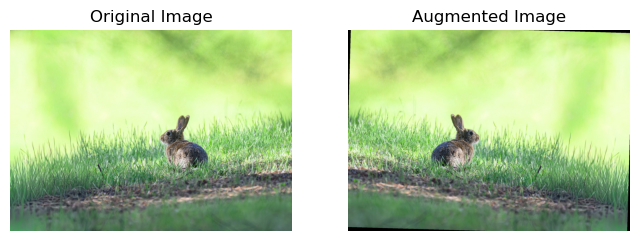

In [9]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Open a minority-class training image
image = Image.open(r"C:\Users\nanda\Downloads\rabbit.jpg").convert("RGB")

# Apply suitable augmentations
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomRotation(degrees=15)
])

augmented_image = augmentation(image)

# Display original and augmented images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title("Augmented Image")
plt.axis("off")

plt.show()

Python explanation:
- Image.open() loads the image file. Replace "rabbit.jpg" with the correct path to your image.
- convert("RGB") ensures the image has three color channels.
- RandomHorizontalFlip(p=1.0) flips the image horizontally every time in this example.
- RandomRotation(degrees=15) rotates the image by a randomly selected angle within the specified range.
- plt.imshow() displays the original and transformed images for comparison.
In a real training pipeline, apply random augmentation to minority-class images during training rather than saving every transformed image permanently.
Type next for Topic 7: Balanced Sampling.

### Simple Concept

Balanced sampling is a technique that helps each class contribute a similar number of image samples during model training.

For an imbalanced dataset, the model may see majority-class images much more frequently than minority-class images.

Balanced sampling changes how images are selected for training so that minority classes receive more attention.

### Example

Suppose our dataset contains:

| Class | Available Images |
|---|---:|
| Cat | 900 |
| Dog | 90 |
| Rabbit | 10 |

With ordinary random sampling, cat images are likely to appear much more frequently.

With balanced sampling, we can select approximately equal numbers of cat, dog, and rabbit images in each training batch.

For example, a batch could contain:

- 10 cat images
- 10 dog images
- 10 rabbit images

### How Does It Work?

1. Identify the classes and their image counts.
2. Assign sampling probabilities or choose a balanced batch-sampling strategy.
3. Sample images for training so that classes receive more balanced representation.
4. Train the model using these batches.
5. Evaluate it on the original validation and test datasets.

### Balanced Sampling vs Oversampling

- **Oversampling:** Increases how frequently minority-class images are selected.
- **Balanced sampling:** A sampling strategy designed to achieve a more balanced class distribution in training batches.

Weighted sampling with replacement is one way to achieve balanced sampling.

### Real-World Example

In animal classification, a dataset might contain many cat images and very few rabbit images. Balanced sampling can help ensure that rabbit images are regularly included in training batches.

### Key Point

Balanced sampling changes which images the model sees during training. It does not necessarily create new images or make the original dataset balanced.

In [10]:
import torch
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# Example labels for 10 images
# 0 = Cat, 1 = Dog, 2 = Rabbit
labels = torch.tensor([0, 0, 0, 0, 0, 0, 1, 1, 2, 2])

# Dummy image data for demonstration
images = torch.randn(10, 3, 32, 32)

dataset = TensorDataset(images, labels)

# Calculate the number of images in each class
class_counts = torch.bincount(labels).float()

# Assign higher sampling weights to minority classes
class_weights = 1.0 / class_counts
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=9,
    replacement=True
)

loader = DataLoader(
    dataset,
    batch_size=3,
    sampler=sampler
)

# Display class counts in the first batch
for batch_images, batch_labels in loader:
    print("Batch labels:", batch_labels.tolist())
    break

Batch labels: [2, 0, 0]


Python explanation:
- TensorDataset combines the sample images and their labels.
- class_counts counts images in each class.
- class_weights assigns greater sampling weights to less frequent classes.
- WeightedRandomSampler selects images using these weights.
- DataLoader groups the selected images into batches of three.
The first batch will contain three sampled images, but it is not guaranteed to contain one image from each class. Weighted sampling balances the expected class distribution over many draws; it does not guarantee perfectly balanced individual batches.

### Simple Concept

After handling class imbalance, we must check whether the model actually improves.

We compare two models:

- **Before handling imbalance:** Train using the original training dataset.
- **After handling imbalance:** Train using a technique such as class weights, oversampling, or balanced sampling.

We evaluate both models on the same unchanged test dataset.

### What Should We Compare?

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** How reliable the model's positive predictions are for each class.
- **Recall:** How many actual images of each class the model identifies correctly.
- **F1-score:** A combined measure of precision and recall.

For imbalanced image classification, pay particular attention to minority-class recall and F1-score.

### Example Results

The following values are illustrative, not results from an actual trained model.

| Metric | Before | After |
|---|---:|---:|
| Accuracy | 95% | 92% |
| Rabbit recall | 0% | 70% |
| Rabbit F1-score | 0% | 65% |

In this example, accuracy decreases slightly, but the model becomes much better at identifying rabbits.

This may be an improvement if identifying rabbits is important to the task.

### Important Point

Handling class imbalance does not always increase accuracy. The objective is to improve useful class-wise performance without creating unacceptable errors on other classes.

Always use the same test images to compare both models fairly. Never balance the test set to make the results look better.

In [11]:
from sklearn.metrics import accuracy_score, classification_report

# Actual test labels
# 0 = Cat, 1 = Dog, 2 = Rabbit
y_true = [0] * 90 + [1] * 9 + [2]

# Predictions before handling imbalance
y_before = [0] * 100

# Illustrative predictions after handling imbalance
y_after = (
    [0] * 85 + [1] * 5 +
    [0] * 4 + [1] * 4 + [2] * 1 +
    [2] * 1
)

# Compare accuracy
print("Before accuracy:", accuracy_score(y_true, y_before))
print("After accuracy:", accuracy_score(y_true, y_after))

# Compare performance for each class
print("\nBefore handling imbalance:")
print(classification_report(
    y_true, y_before,
    labels=[0, 1, 2],
    target_names=["Cat", "Dog", "Rabbit"],
    zero_division=0
))

print("\nAfter handling imbalance:")
print(classification_report(
    y_true, y_after,
    labels=[0, 1, 2],
    target_names=["Cat", "Dog", "Rabbit"],
    zero_division=0
))

Before accuracy: 0.9
After accuracy: 0.9

Before handling imbalance:
              precision    recall  f1-score   support

         Cat       0.90      1.00      0.95        90
         Dog       0.00      0.00      0.00         9
      Rabbit       0.00      0.00      0.00         1

    accuracy                           0.90       100
   macro avg       0.30      0.33      0.32       100
weighted avg       0.81      0.90      0.85       100


After handling imbalance:
              precision    recall  f1-score   support

         Cat       0.96      0.94      0.95        90
         Dog       0.44      0.44      0.44         9
      Rabbit       0.50      1.00      0.67         1

    accuracy                           0.90       100
   macro avg       0.63      0.80      0.69       100
weighted avg       0.90      0.90      0.90       100

